# Predicting Heart Disease (Kaggle PS S6E2) — EDA

**Task:** binary classification — predict `Heart Disease` (`Presence`/`Absence`) from 13
features on the classic UCI Statlog Heart schema (5 numeric, 8 low-cardinality
categorical/ordinal-int). **Metric: ROC AUC** (higher is better; confirmed via the Kaggle
API `evaluationMetric` field, not visible on the JS-rendered web page).

This notebook answers: **target balance · numeric & categorical distributions · feature↔target
signal (correlations, per-category positive rates, mutual information, single-feature baseline
AUC) · duplicates · train/test drift**. Figures → `reports/figures/`; written conclusions →
`reports/EDA_FINDINGS.md`.

In [1]:
%matplotlib inline
import pathlib, sys
_root = pathlib.Path.cwd()
if not (_root / "data").exists():   # notebook runs from notebooks/
    _root = _root.parent
sys.path.insert(0, str(_root))      # make `src` importable regardless of cwd

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")
RAW = _root / "data" / "raw"
FIG = _root / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

TARGET = "Heart Disease"
NUMERIC = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
CATEGORICAL = ["Sex", "Chest pain type", "FBS over 120", "EKG results", "Exercise angina",
               "Slope of ST", "Number of vessels fluro", "Thallium"]

train = pd.read_csv(RAW / "train.csv")
test = pd.read_csv(RAW / "test.csv")
train["y"] = (train[TARGET] == "Presence").astype(int)
print("train", train.shape, " test", test.shape)
print("missing cells — train:", int(train.isna().sum().sum()), " test:", int(test.isna().sum().sum()))
print("duplicate feature rows in train:",
      int(train.drop(columns=['id', TARGET, 'y']).duplicated().sum()))
print("duplicate feature rows in test:", int(test.drop(columns=['id']).duplicated().sum()))
train.head()

train (630000, 16)  test (270000, 14)
missing cells — train: 0  test: 0
duplicate feature rows in train: 0
duplicate feature rows in test: 0


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,y
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence,1


## Target balance

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64
positive rate (Presence) = 0.4483


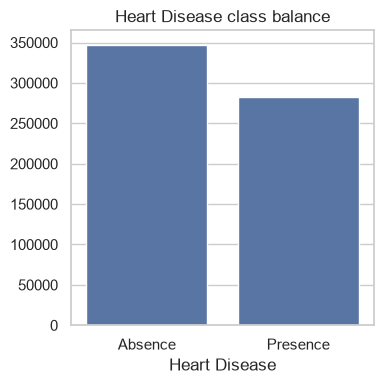

In [2]:
counts = train[TARGET].value_counts()
print(counts)
print(f"positive rate (Presence) = {train['y'].mean():.4f}")

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax)
ax.set_title("Heart Disease class balance")
fig.tight_layout(); fig.savefig(FIG / "target_balance.png", dpi=110); plt.show()

## Numeric feature distributions (by class)

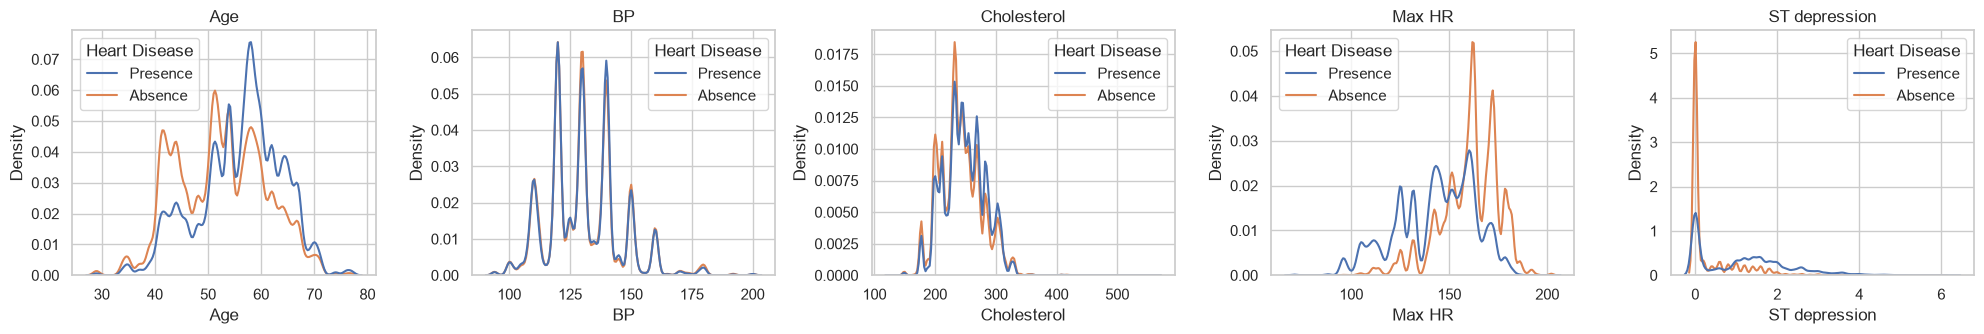

              Age          BP  Cholesterol      Max HR  ST depression
count  630000.000  630000.000   630000.000  630000.000     630000.000
mean       54.137     130.497      245.012     152.817          0.716
std         8.256      14.976       33.682      19.113          0.948
min        29.000      94.000      126.000      71.000          0.000
25%        48.000     120.000      223.000     142.000          0.000
50%        54.000     130.000      243.000     157.000          0.100
75%        60.000     140.000      269.000     166.000          1.400
max        77.000     200.000      564.000     202.000          6.200


In [3]:
fig, axes = plt.subplots(1, len(NUMERIC), figsize=(4 * len(NUMERIC), 3.5))
for ax, c in zip(axes, NUMERIC):
    sns.kdeplot(data=train, x=c, hue=TARGET, ax=ax, common_norm=False)
    ax.set_title(c)
fig.tight_layout(); fig.savefig(FIG / "numeric_distributions.png", dpi=110); plt.show()
print(train[NUMERIC].describe().round(3))

## Numeric ↔ target correlation

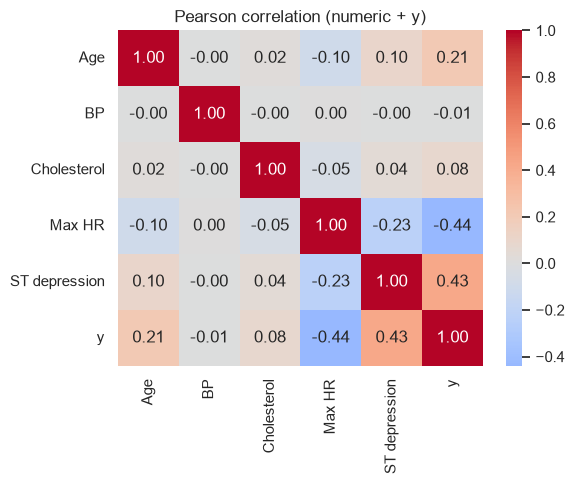

Pearson r with y (Presence=1):
Max HR          -0.4410
ST depression    0.4306
Age              0.2121
Cholesterol      0.0828
BP              -0.0052
Name: y, dtype: float64


In [4]:
corr = train[NUMERIC + ["y"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Pearson correlation (numeric + y)")
fig.tight_layout(); fig.savefig(FIG / "numeric_correlation.png", dpi=110); plt.show()
print("Pearson r with y (Presence=1):")
print(corr["y"].drop("y").sort_values(key=np.abs, ascending=False).round(4))

## Categorical feature ↔ target (positive rate by level)

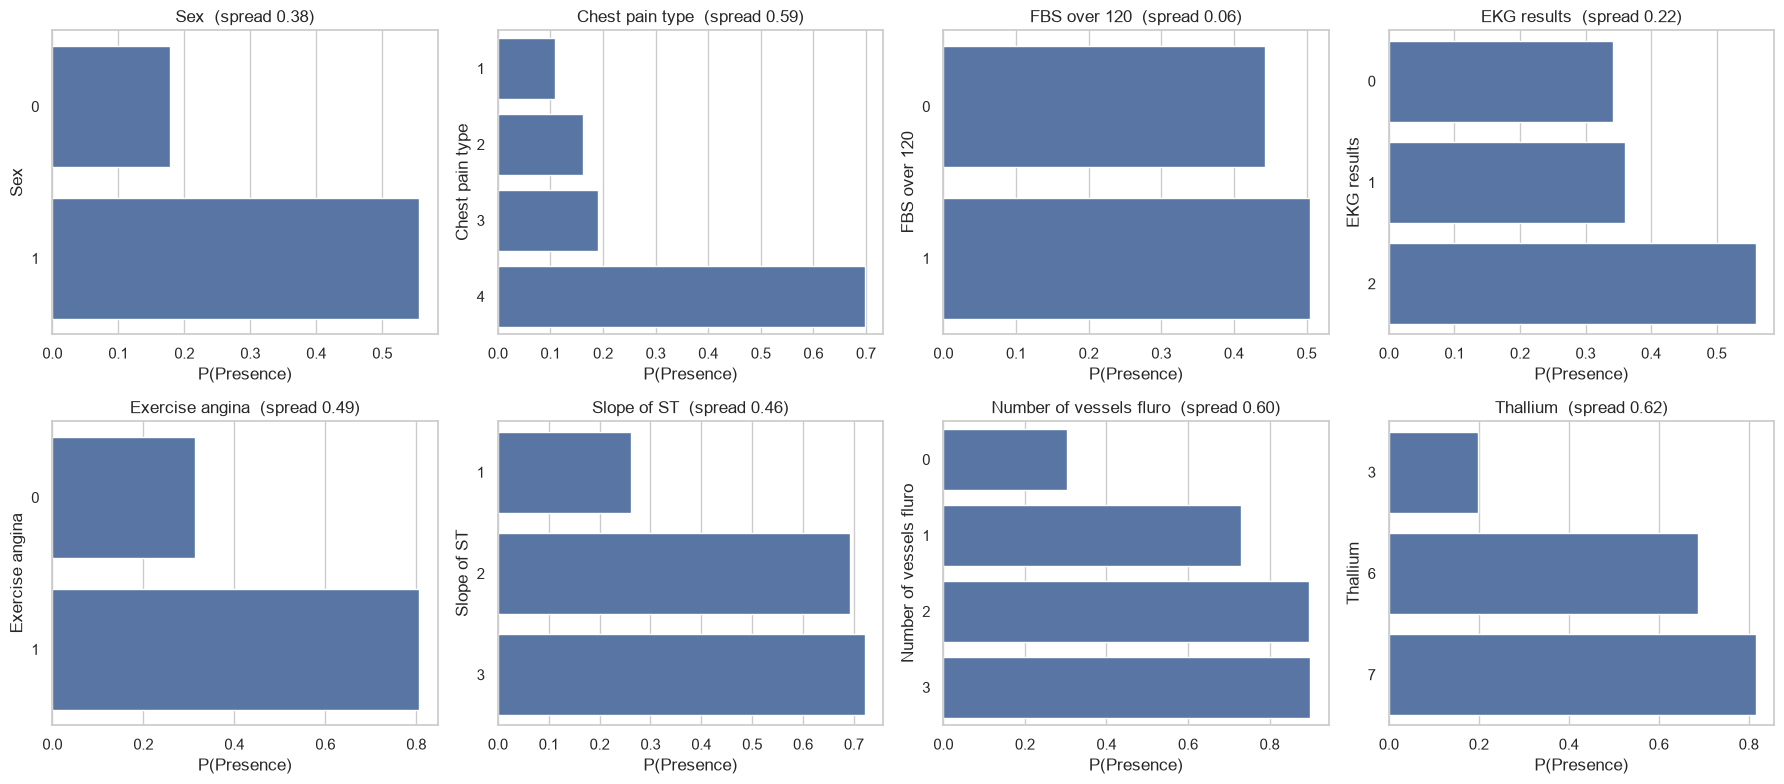

Pearson r with y, and positive-rate spread by categorical (max level - min level):
  Thallium                 r=+0.606  spread=0.617
  Chest pain type          r=+0.461  spread=0.589
  Exercise angina          r=+0.442  spread=0.493
  Number of vessels fluro  r=+0.439  spread=0.596
  Slope of ST              r=+0.415  spread=0.459
  Sex                      r=+0.342  spread=0.377
  EKG results              r=+0.219  spread=0.218
  FBS over 120             r=+0.034  spread=0.062


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8)); axes = axes.ravel()
spread = {}
corr_cat = {}
for ax, c in zip(axes, CATEGORICAL):
    g = train.groupby(c, observed=True)["y"].mean().sort_values()
    spread[c] = float(g.max() - g.min())
    corr_cat[c] = float(train[[c, "y"]].corr().iloc[0, 1])
    sns.barplot(x=g.values, y=g.index.astype(str), ax=ax, orient="h")
    ax.set_title(f"{c}  (spread {spread[c]:.2f})"); ax.set_xlabel("P(Presence)")
for ax in axes[len(CATEGORICAL):]:
    ax.axis("off")
fig.tight_layout(); fig.savefig(FIG / "per_category_rates.png", dpi=110); plt.show()
print("Pearson r with y, and positive-rate spread by categorical (max level - min level):")
for c in sorted(CATEGORICAL, key=lambda c: -abs(corr_cat[c])):
    print(f"  {c:24s} r={corr_cat[c]:+.3f}  spread={spread[c]:.3f}")

## Mutual information with the target

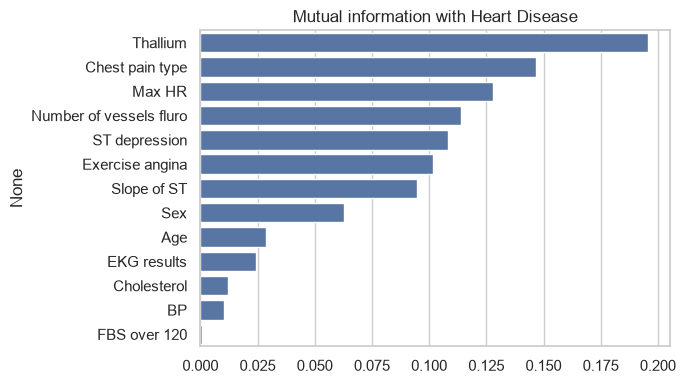

Thallium                   0.1955
Chest pain type            0.1467
Max HR                     0.1280
Number of vessels fluro    0.1141
ST depression              0.1082
Exercise angina            0.1016
Slope of ST                0.0949
Sex                        0.0629
Age                        0.0286
EKG results                0.0242
Cholesterol                0.0120
BP                         0.0103
FBS over 120               0.0006
dtype: float64


In [6]:
X = train[NUMERIC + CATEGORICAL].copy()
cat_idx = [X.columns.get_loc(c) for c in CATEGORICAL]
mi = mutual_info_classif(X, train["y"], discrete_features=cat_idx, random_state=42)
mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=mi.values, y=mi.index, ax=ax); ax.set_title("Mutual information with Heart Disease")
fig.tight_layout(); fig.savefig(FIG / "mutual_information.png", dpi=110); plt.show()
print(mi.round(4))

## Single-feature baseline AUC (signal strength)

In [7]:
# For each feature, score AUC using the per-bin/per-level positive rate as the predicted
# probability (10 quantile bins for numeric, each level for categorical) — an out-of-model
# measure of how much each feature alone explains, on the actual competition metric.
rows = []
for c in NUMERIC:
    b = pd.qcut(train[c], 10, duplicates="drop")
    pred = train.groupby(b, observed=True)["y"].transform("mean")
    rows.append((c, roc_auc_score(train["y"], pred)))
for c in CATEGORICAL:
    pred = train.groupby(c, observed=True)["y"].transform("mean")
    rows.append((c, roc_auc_score(train["y"], pred)))
sf = pd.DataFrame(rows, columns=["feature", "binned_mean_AUC"]).sort_values(
    "binned_mean_AUC", ascending=False)
print(sf.to_string(index=False))

                feature  binned_mean_AUC
               Thallium         0.800778
        Chest pain type         0.768271
                 Max HR         0.755330
          ST depression         0.730416
Number of vessels fluro         0.714848
            Slope of ST         0.714527
        Exercise angina         0.698074
                    Sex         0.655460
                    Age         0.625170
            EKG results         0.610163
            Cholesterol         0.556824
                     BP         0.514986
           FBS over 120         0.509156


## Train/test drift

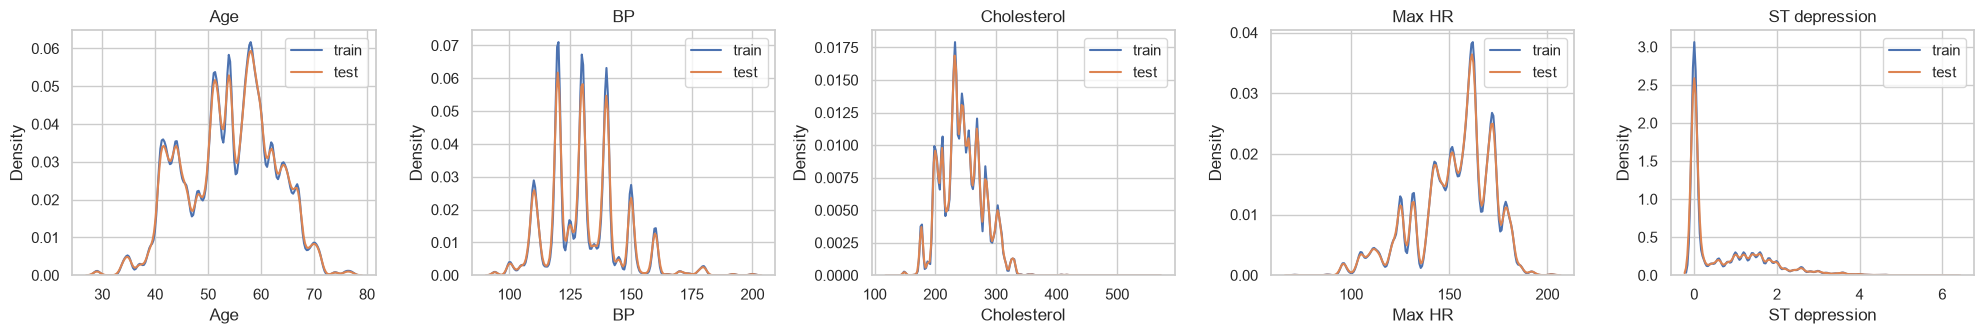

numeric mean train vs test:
                 train     test
Age             54.137   54.160
BP             130.497  130.555
Cholesterol    245.012  245.045
Max HR         152.817  152.784
ST depression    0.716    0.718
  Sex: max |train-test| level share diff = 0.0016
  Chest pain type: max |train-test| level share diff = 0.0021
  FBS over 120: max |train-test| level share diff = 0.0001
  EKG results: max |train-test| level share diff = 0.0016
  Exercise angina: max |train-test| level share diff = 0.0009
  Slope of ST: max |train-test| level share diff = 0.0031
  Number of vessels fluro: max |train-test| level share diff = 0.0022
  Thallium: max |train-test| level share diff = 0.0003


In [8]:
fig, axes = plt.subplots(1, len(NUMERIC), figsize=(4 * len(NUMERIC), 3.5))
for ax, c in zip(axes, NUMERIC):
    sns.kdeplot(train[c], ax=ax, label="train"); sns.kdeplot(test[c], ax=ax, label="test")
    ax.set_title(c); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "train_test_drift.png", dpi=110); plt.show()
print("numeric mean train vs test:")
print(pd.DataFrame({"train": train[NUMERIC].mean(), "test": test[NUMERIC].mean()}).round(3))
for c in CATEGORICAL:
    tr = train[c].value_counts(normalize=True)
    te = test[c].value_counts(normalize=True)
    print(f"  {c}: max |train-test| level share diff = {(tr - te).abs().max():.4f}")